In [1]:
from env import (
    MultiLeafThreadEnv,
    ThreadingConfig,
)
import torch
import random
from viz import draw_local_tree_sequence, draw_tree_edge_index
# from utils import _timed_tree_to_graph_full
import matplotlib.pyplot as plt

from utils import build_backbone_segments_from_reference
from viz import draw_local_tree_sequence
from utils import get_max_actions
from utils import MultiLeafState

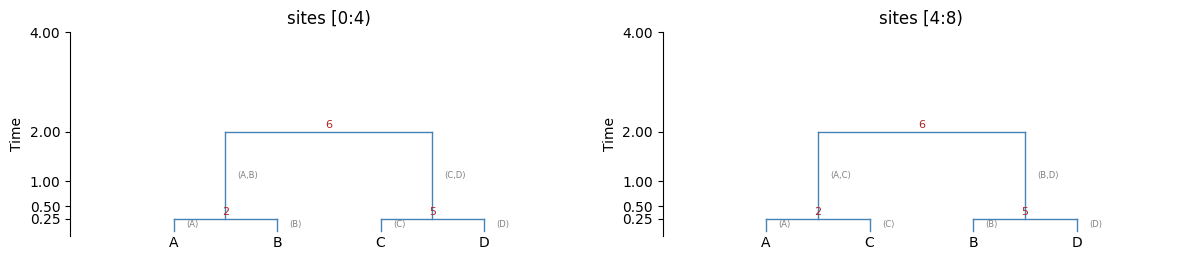

In [2]:
## First example
REFERENCE_FULL_TREES = [
    {
        "sites": (0, 4),
        # "tree": ("n", 2.0, ("n", 1.0, ("n", 1.0, 0, 1), 2), 3),
        "tree": ("n", 2.0, ("n", 0.25, 0, 1), ("n", 0.25, 2, 3)),
    },
    {
        "sites": (4, 8),
        "tree": ("n", 2.0, ("n", 0.25, 0, 2), ("n", 0.25, 1, 3)),
    },
]

GENO = torch.tensor(
    [
        [0, 0, 0, 0, 0, 0, 0, 0], #A
        [0, 0, 0, 0, 1, 1, 1, 1], #B
        [1, 1, 1, 1, 0, 0, 0, 0], #C
        [1, 1, 1, 1, 1, 1, 1, 1], #D
    ],
    dtype=torch.long,
)
LEAF_NAMES = ["A", "B", "C", "D"]
ALL_LEAF_IDS = [0, 1, 2, 3]
TIME_GRID = (0.25, 0.5, 1.0, 2.0, 4.0)

## View this tree. 

full_tree_backbone = build_backbone_segments_from_reference(REFERENCE_FULL_TREES, focal_leaf=-1)
draw_local_tree_sequence(full_tree_backbone, leaf_names=LEAF_NAMES, time_grid=TIME_GRID, use_time_as_y=True)


In [3]:
multi_env_cfg = ThreadingConfig.from_raw(GENO, TIME_GRID, 0.4, 0.35, 0.15)
env = MultiLeafThreadEnv(multi_env_cfg, ALL_LEAF_IDS, REFERENCE_FULL_TREES)

In [4]:
st = env.reset()

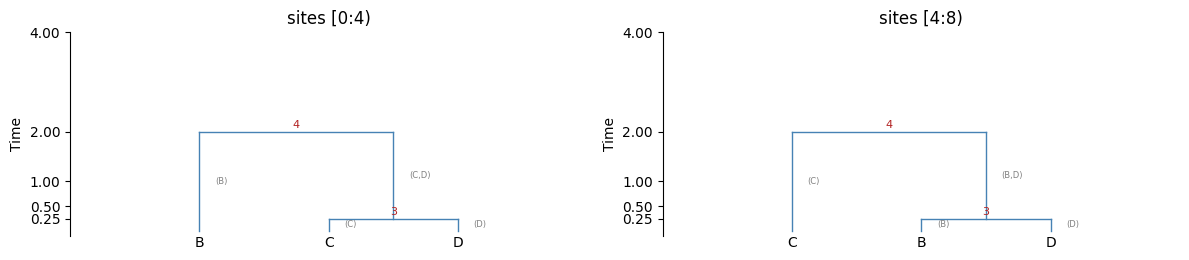

In [5]:
draw_local_tree_sequence(env._inner_env.backbone_segments, leaf_names=LEAF_NAMES, time_grid=TIME_GRID, use_time_as_y=True)


In [6]:
from models import GFlowNetForwardPolicy

In [7]:

# 1. Configuration parameters
B = 2          # Batch size
N = 10         # Number of nodes in the local tree
T = 4         # Number of discrete time bins
d_model = 64   # Hidden dimension

model = GFlowNetForwardPolicy(
    input_dim=4, 
    d_model=d_model, 
    n_heads=4, 
    num_layers=2, 
    num_time_bins=len(TIME_GRID)
)

In [8]:
from train import TBLoss, train_gflownet
import torch.optim as optim

In [9]:
env.reset()

tb_loss_module = TBLoss(init_log_z=0.0)
model_optimizer = optim.Adam(model.parameters(), lr=1e-4)
z_optimizer = optim.Adam(tb_loss_module.parameters(), lr=1e-3) # Often higher LR for Z
optimizers = [model_optimizer, z_optimizer]

window_data = GENO.t().float() # Shape will be [8, 4]
# For a single sequence dataset, the dataloader is just a list with one item!
dataloader = [window_data]

print("Starting training...")
train_gflownet(
    model=model, 
    tb_loss_module=tb_loss_module, 
    optimizers=optimizers, 
    dataloader=dataloader, 
    env=env, # Replace None with your instantiated env
    epochs=10
)
print("Finished 1 epoch!")

Starting training...
Epoch 1/10 - TB Loss: 61.8054
Epoch 2/10 - TB Loss: 37.5361
Epoch 3/10 - TB Loss: 34.1788
Epoch 4/10 - TB Loss: 34.9660
Epoch 5/10 - TB Loss: 60.9511
Epoch 6/10 - TB Loss: 51.0246
Epoch 7/10 - TB Loss: 56.6766
Epoch 8/10 - TB Loss: 48.9521
Epoch 9/10 - TB Loss: 23.0561
Epoch 10/10 - TB Loss: 52.5692
Model saved to gflownet_model.pt
Finished 1 epoch!


In [10]:
from inference import load_and_sample
from models import GFlowNetForwardPolicy

# The model path saved from train_gflownet
model_path = "gflownet_model.pt"

# The same hyperparameters you used to initialize the model for training
model_kwargs = {
    "input_dim": 4, 
    "d_model": 64, 
    "n_heads": 4, 
    "num_layers": 2, 
    "num_time_bins": len(TIME_GRID)
}

# The window data used in training
window_data = GENO.t().float()

print("Loading model and sampling 10 ARGs...")

# Run the inference sampling method
sampled_args = load_and_sample(
    model_class=GFlowNetForwardPolicy,
    model_kwargs=model_kwargs,
    model_path=model_path,
    env=env,
    window_alleles=window_data,
    num_samples=10, 
    device='cpu' # Change to 'cuda:0' if you are using GPU
)

print(f"\nSuccessfully sampled {len(sampled_args)} ARGs from the posterior.")

# You can now inspect one of the terminal state ARGs!
print(sampled_args[0])


Loading model and sampling 10 ARGs...
Successfully loaded model from gflownet_model.pt
Sampling 10 ARGs from the posterior...
Completed sampling 10 ARGs.

Successfully sampled 10 ARGs from the posterior.
MultiLeafState(current_full_trees=({'sites': (0, 1), 'tree': ('n', 4.0, ('n', 4.0, 0, 2), ('n', 2.0, 1, 3))}, {'sites': (1, 2), 'tree': ('n', 1.0, ('n', 1.0, 0, ('n', 0.5, 1, 3)), 2)}, {'sites': (2, 3), 'tree': ('n', 4.0, ('n', 4.0, 1, 2), ('n', 1.0, 0, 3))}, {'sites': (3, 4), 'tree': ('n', 4.0, ('n', 1.0, 1, ('n', 0.25, 0, 3)), 2)}, {'sites': (4, 5), 'tree': ('n', 4.0, ('n', 2.0, 0, ('n', 2.0, 1, 2)), 3)}, {'sites': (5, 6), 'tree': ('n', 4.0, ('n', 2.0, 1, ('n', 1.0, 0, 3)), 2)}, {'sites': (6, 7), 'tree': ('n', 2.0, ('n', 0.25, 2, ('n', 0.25, 0, 3)), 1)}, {'sites': (7, 8), 'tree': ('n', 2.0, ('n', 0.5, 0, 2), ('n', 0.5, 1, 3))}), leaves_threaded=(0, 1, 2, 3), current_focal_leaf=None, inner_state=None)


10